# Developing the Agent logic

The whole point of the project is to find a way to use the differences of
performance which have proven to maybe be useful.

The steps to follow are according to the logical order of training with replay
buffer

0. Preparation for buffer (indexing and data-structure)
1. Feeding "forward pass" - including a simple actor
2. Sampling
3. training logic with buffer

In [1]:
import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)


from thesis.helper_scripts.general import extract_objs_from_sim_dir
from thesis.helper_scripts.hypothesis_visualization import simulation_counts_per_round

from berebasl.simulation.credit_data_simulation import CreditData, CreditDataSample


sim_objs = extract_objs_from_sim_dir(
    grid_path='../berebasl/data/simulations/mnar_grid_hyp_testing',
    sim_dir='bias_0_0_corr_0_2',
    device=torch.device('cpu')
)
credit_data = sim_objs["credit_data"]

In [ ]:
from typing import Literal, Dict
from copy import deepcopy
from matplotlib import pyplot as plt

class CreditDataManager:
    def __init__(
            self,
            sim_objs: dict,
            wished_acc_base: Literal["roc", "ks"]
        ):
        self.credit_data = deepcopy(sim_objs["credit_data"])
        self.wished_acc_base = wished_acc_base
        key_wanted_acc = "acc_based_" + wished_acc_base
        alternative_accepted = sim_objs["alternative_accepted"]
        if key_wanted_acc in alternative_accepted:
            self.credit_data.change_acceptance_flag(alternative_accepted[key_wanted_acc])

        counts, th_meaning = simulation_counts_per_round(sim_objs)
        idx_wanted = [i for i, k in enumerate(th_meaning) if k == key_wanted_acc]
        assert len(idx_wanted) == 1
        idx_wanted = idx_wanted[0]

        self.counts_wished = counts[idx_wanted] # [AR, TBG, G]

    @property
    def N_acc(self):
        return self.credit_data.count_accepts
    
    @property
    def N_rej(self):
        return self.credit_data.count_rejects
    
    @property
    def N(self):
        return self.credit_data.count_all
    
    @property
    def F(self):
        return self.credit_data.features_count

    @property
    def mask_gens_with_defaults(self):
        return self.counts_wished[0, 1] > 0

    def plot_defaults_among_acc(self, title: str= '') -> None:
        accepted_defaults = self.counts_wished[0, 1, 1:].cpu()
        rounds = torch.arange(1, self.credit_data.last_gen_round+1, device=accepted_defaults.device)

        mask_was_zero = accepted_defaults==0

        plt.plot(rounds, accepted_defaults, label="Defaults count")
        plt.scatter(rounds[mask_was_zero], accepted_defaults[mask_was_zero], s=5, c='red', label="Points with Zero Defaults")

        plt.ylabel("Defaults among accepts")
        plt.xlabel("Generation round")

        plt.legend()
        plt.show()

    def get_round_ids_with_no_defaults_among_acc(self) -> torch.Tensor:
        accepted_defaults = self.counts_wished[0, 1]
        rounds = torch.arange(0, self.credit_data.last_gen_round+1, device=accepted_defaults.device)
        return rounds[accepted_defaults==0]

    def set_maximal_gen_round(self, gen_round: int):
        if not (0 <= gen_round <= self.credit_data.last_gen_round):
            raise AssertionError(f"gen_round has to be between 0 and self.credit_data.last_gen_round={self.credit_data.last_gen_round}")
        
        mask_keep = self.credit_data.gen_round <= gen_round

        attr_to_cut = ["features", "default_flag", "accepted", "gen_round"]
        for a in attr_to_cut:
            setattr(self.credit_data, a, getattr(self.credit_data, a)[mask_keep])

        self.credit_data.change_acceptance_flag(self.credit_data.accepted)
        self.counts_wished = self.counts_wished[..., :gen_round+1]
        


buffer = CreditDataManager(sim_objs, wished_acc_base="roc")

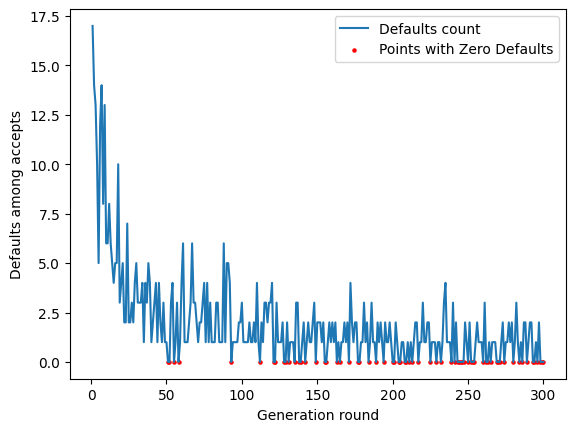

In [54]:
buffer.plot_defaults_among_acc("Defaults Among Accepts per round")

In [55]:
rounds_without_defaults = buffer.get_round_ids_with_no_defaults_among_acc()
round_to_pick_as_maximal = rounds_without_defaults[(rounds_without_defaults > 100).nonzero()[0,0]].item() - 1
print("Round to pick as maximal:", round_to_pick_as_maximal)

buffer.set_maximal_gen_round(round_to_pick_as_maximal)

Round to pick as maximal: 111


tensor(111)